# Fine-Tune Open Weight Language Models for Function Calling in Strands Agents

[![License](https://img.shields.io/badge/License-Apache%202.0-blue.svg)](https://opensource.org/licenses/Apache-2.0)
[![Python 3.10+](https://img.shields.io/badge/python-3.10+-blue.svg)](https://www.python.org/downloads/)

## Introduction

This notebook demonstrates how to fine-tune small language models (1-3B parameters) for reliable function calling in edge environments. We leverage optimized training pipelines to achieve 2-5x faster training with 50% less memory usage compared to standard implementations.

Function calling, also known as tool use, enables language models to interact with external systems through structured API calls. This is critical for edge deployment where models must control physical devices, query databases, or invoke services with high reliability.

### The Problem We're Solving

Edge devices in vehicles and industrial settings need AI assistants that can:
- **Understand natural language**: "It's too hot" → climate control
- **Execute actions locally**: No cloud dependency for critical controls
- **Work with limited resources**: 2-4GB RAM, no GPU required
- **Maintain high accuracy**: Safety-critical operations demand reliability

### Our Solution: Fine-Tuned Tool Calling

Instead of using a general-purpose model, we specialize Qwen3-1.7B for specific tools:

```mermaid
graph LR
    A[User Input:<br/>'Set the temperature to 72 degrees'] --> B[Model Recognition:<br/>Intent = climate_control<br/>Parameter = 72]
    B --> C[Strands Format:<br/>toolUse.name: climate_control<br/>toolUse.input.command: 'set to 72']
    C --> D[Agent Execution:<br/>Virtual ECU updates<br/>climate state]
    D --> E[User Feedback:<br/>'Temperature set to 72°F']
    
    style A fill:#e1f5fe
    style B fill:#fff3e0
    style C fill:#f3e5f5
    style D fill:#e8f5e9
    style E fill:#fce4ec
```

### What You'll Learn

- Generate high-quality synthetic training data using teacher-student approaches
- Fine-tune models efficiently using LoRA (Low-Rank Adaptation)
- Quantize models for edge deployment while preserving accuracy
- Benchmark performance improvements systematically
- Deploy models using llama.cpp for production inference

### Understanding Model Quantization

Quantization is the process of reducing numerical precision to compress models while preserving performance. In neural networks, weights and activations typically use 32-bit (FP32) or 16-bit (FP16/BF16) floating-point numbers. Quantization reduces these to 8-bit integers or even 4-bit representations, achieving:

- **Size Reduction**: 4-bit quantization reduces model size by ~75% compared to FP16
- **Speed Improvement**: Integer operations are faster than floating-point on most hardware
- **Memory Efficiency**: Enables deployment on resource-constrained edge devices
- **Minimal Accuracy Loss**: Modern quantization methods preserve >99% of model quality

#### Quantization Methods

**K-means Quantization (K-quants)**: Groups similar weights into clusters, storing cluster indices instead of full values. The 'K' variants (Q4_K_M, Q5_K_M) use different bit allocations for different tensor components.

**Dynamic vs Static**: Dynamic quantization determines scale factors at runtime, while static uses pre-computed values. We use static for predictable edge performance.

**Mixed Precision**: Critical layers (like embeddings) maintain higher precision while less sensitive layers use aggressive quantization.

## 🔧 Install Dependencies & Build Tools

This cell installs all required dependencies and builds llama.cpp for GGUF operations.
**Run this cell first** - it may take 5-10 minutes to complete.

### What this installs:
- **Python packages**: PyTorch, transformers, PEFT, GGUF, etc.
- **llama.cpp**: Cloned and compiled for GGUF conversion and inference
- **System tools**: Build essentials, CMake, etc.

### Requirements:
- **GPU**: CUDA-capable GPU recommended for training
- **Memory**: 8GB+ RAM for model operations
- **Storage**: 10GB+ free space for models and tools

### Step 1: Install System Dependencies

Install build tools and system libraries required for compiling llama.cpp.

In [1]:
print("📦 Installing system dependencies...")
print("This may require sudo password for package installation.")

📦 Installing system dependencies...
This may require sudo password for package installation.


In [2]:
# Update package lists
!sudo apt-get update -qq

In [3]:
# Install build essentials and development tools
!sudo apt-get install -y build-essential cmake git wget curl

Reading package lists... Done


Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.10ubuntu1).
cmake is already the newest version (3.28.3-1build7).
git is already the newest version (1:2.43.0-1ubuntu7.3).
wget is already the newest version (1.21.4-1ubuntu4.1).
curl is already the newest version (8.5.0-2ubuntu10.6).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [4]:
# Install additional libraries for llama.cpp (including CURL)
!sudo apt-get install -y pkg-config libssl-dev libcurl4-openssl-dev

Reading package lists... Done


Building dependency tree... Done
Reading state information... Done
pkg-config is already the newest version (1.8.1-2build1).
libssl-dev is already the newest version (3.0.13-0ubuntu3.5).
libcurl4-openssl-dev is already the newest version (8.5.0-2ubuntu10.6).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


### Step 2: Install Python Dependencies

Install all required Python packages using uv package manager.

In [5]:
print("🐍 Installing Python dependencies with uv...")
print("This includes PyTorch, transformers, PEFT, GGUF, and all other requirements.")

🐍 Installing Python dependencies with uv...
This includes PyTorch, transformers, PEFT, GGUF, and all other requirements.


In [6]:
# Install Python dependencies using uv
!cd ../../ && uv sync --extra dev --extra ml --extra function-calling

Resolved 235 packages in 10ms
Audited 197 packages in 0.23ms


### Step 3: Clone llama.cpp Repository

Clone the official llama.cpp repository for GGUF conversion and inference tools.

In [7]:
import os
from pathlib import Path

print("🦙 Setting up llama.cpp...")
llamacpp_dir = Path("./llama.cpp")

if llamacpp_dir.exists():
    print("📁 llama.cpp directory already exists")
else:
    print("📥 Cloning llama.cpp repository...")

🦙 Setting up llama.cpp...
📁 llama.cpp directory already exists


In [8]:
# Clone llama.cpp if not already present
!if [ ! -d "./llama.cpp" ]; then \
    git clone https://github.com/ggerganov/llama.cpp.git; \
else \
    echo "Directory exists, updating..."; \
    cd llama.cpp && git pull; \
fi

Directory exists, updating...
Already up to date.


### Step 4: Check CUDA Availability

Detect if CUDA is available for GPU-accelerated compilation.

In [9]:
# Check CUDA availability
!echo "🔍 Checking for CUDA..."
!if command -v nvcc &> /dev/null; then \
    echo "🎮 CUDA detected:"; \
    nvcc --version | head -n 4; \
    echo "Will build with GPU support"; \
else \
    echo "💻 CUDA not found, will build CPU-only version"; \
fi

🔍 Checking for CUDA...
🎮 CUDA detected:
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Wed_Jul_16_07:30:01_PM_PDT_2025
Cuda compilation tools, release 13.0, V13.0.48
Will build with GPU support


### Step 5: Build llama.cpp

Compile llama.cpp with appropriate optimizations (GPU if available, CPU otherwise).

In [10]:
print("🔨 Building llama.cpp...")
print("This may take 3-5 minutes depending on your system.")

🔨 Building llama.cpp...
This may take 3-5 minutes depending on your system.


In [11]:
# Clean any previous build attempts and build llama.cpp with CMake
!cd llama.cpp && rm -rf build && \
if command -v nvcc &> /dev/null; then \
    echo "🎮 Building with CUDA support using CMake..."; \
    echo "CUDA Compute Capabilities: Detecting automatically..."; \
    cmake -B build -DGGML_CUDA=ON -DCMAKE_BUILD_TYPE=Release -DLLAMA_CURL=OFF; \
    cmake --build build --config Release -j $(nproc); \
else \
    echo "💻 Building CPU-only version using CMake..."; \
    cmake -B build -DCMAKE_BUILD_TYPE=Release -DLLAMA_CURL=OFF; \
    cmake --build build --config Release -j $(nproc); \
fi && \
echo "✅ Build completed! Binaries are in build/bin/"

🎮 Building with CUDA support using CMake...
CUDA Compute Capabilities: Detecting automatically...
-- The C compiler identification is GNU 13.3.0
-- The CXX compiler identification is GNU 13.3.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
CMAKE_BUILD_TYPE=Release
-- Found Git: /usr/bin/git (found version "2.43.0") 
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE  
-- Warning: ccache not found - consider installing it for faster compilation or disable this warning with GGML_CCACHE=OFF
-- CMAKE_SYSTEM_PROCESSOR: x86_64
-- GGML_SYSTEM_ARCH: x86
-- Including CPU 

### Step 6: Verify Installation

Check that all components are properly installed and working.

In [6]:
# Verify Python packages
print("🧪 Verifying Python packages...")
try:
    import torch
    print(f"   ✅ PyTorch: {torch.__version__}")
except ImportError:
    print("   ❌ PyTorch: Not available")

try:
    import transformers
    print(f"   ✅ Transformers: {transformers.__version__}")
except ImportError:
    print("   ❌ Transformers: Not available")

try:
    import peft
    print(f"   ✅ PEFT: {peft.__version__}")
except ImportError:
    print("   ❌ PEFT: Not available")

try:
    import gguf
    # GGUF package doesn't have __version__, just check if it imports
    print(f"   ✅ GGUF: Available (from llama.cpp)")
except ImportError:
    print("   ❌ GGUF: Not available")
except AttributeError:
    print("   ✅ GGUF: Available (version info not accessible)")

🧪 Verifying Python packages...
   ✅ PyTorch: 2.8.0+cu128


/home/ubuntu/samples-dev/02-samples/14-agentic-ai-at-the-edge/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   ✅ Transformers: 4.55.4
   ✅ PEFT: 0.14.0
   ✅ GGUF: Available (from llama.cpp)


In [7]:
# Verify llama.cpp binaries (CMake build directory)
print("🔧 Verifying llama.cpp binaries...")
from pathlib import Path

llamacpp_dir = Path("./llama.cpp")
build_dir = llamacpp_dir / "build" / "bin"
key_binaries = ["llama-server", "llama-quantize"]
key_scripts = ["convert_hf_to_gguf.py"]

print(f"Looking for binaries in: {build_dir}")

for binary in key_binaries:
    binary_path = build_dir / binary
    if binary_path.exists():
        print(f"   ✅ {binary}: Available at {binary_path}")
    else:
        print(f"   ❌ {binary}: Missing from {binary_path}")

print(f"\nLooking for Python scripts in: {llamacpp_dir}")

for script in key_scripts:
    script_path = llamacpp_dir / script
    if script_path.exists():
        print(f"   ✅ {script}: Available at {script_path}")
    else:
        print(f"   ❌ {script}: Missing from {script_path}")

# Also check if build directory exists
if not build_dir.exists():
    print(f"   ⚠️  Build directory not found: {build_dir}")
    print("   This suggests the CMake build may have failed.")

🔧 Verifying llama.cpp binaries...
Looking for binaries in: llama.cpp/build/bin
   ✅ llama-server: Available at llama.cpp/build/bin/llama-server
   ✅ llama-quantize: Available at llama.cpp/build/bin/llama-quantize

Looking for Python scripts in: llama.cpp
   ✅ convert_hf_to_gguf.py: Available at llama.cpp/convert_hf_to_gguf.py


In [14]:
# Installation summary
print("\n" + "=" * 60)
print("🎯 INSTALLATION COMPLETE!")
print("=" * 60)
print("✅ System dependencies installed")
print("✅ Python packages installed")
print("✅ llama.cpp cloned and built")
print("✅ GGUF tools ready")
print("\n🚀 Ready to proceed with fine-tuning!")
print("\n📋 Next steps:")
print("   1. Run the training cells to fine-tune your model")
print("   2. Convert to GGUF format for edge deployment")
print("   3. Test with: ./llama.cpp/build/bin/llama-server -m model.gguf")
print("   4. Deploy to production edge devices")
print("\n💡 Tips:")
print("   - If any step failed, you can re-run individual cells above")
print("   - Binaries are located in: ./llama.cpp/build/bin/")
print("   - For CUDA builds, ensure your GPU has sufficient VRAM")


🎯 INSTALLATION COMPLETE!
✅ System dependencies installed
✅ Python packages installed
✅ llama.cpp cloned and built
✅ GGUF tools ready

🚀 Ready to proceed with fine-tuning!

📋 Next steps:
   1. Run the training cells to fine-tune your model
   2. Convert to GGUF format for edge deployment
   3. Test with: ./llama.cpp/build/bin/llama-server -m model.gguf
   4. Deploy to production edge devices

💡 Tips:
   - If any step failed, you can re-run individual cells above
   - Binaries are located in: ./llama.cpp/build/bin/
   - For CUDA builds, ensure your GPU has sufficient VRAM


In [15]:
%%capture
# Quick dependency check (run this if you skipped the full installation above)
!uv pip install -q --upgrade pip
!cd ../../ && uv sync --extra dev --extra ml --extra function-calling

In [14]:
# Imports
import json
import torch
from pathlib import Path
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, TaskType, get_peft_model, PeftModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## Data Preparation

### Optional: Generate Custom Training Data

This notebook includes pre-generated training data (651 examples) and test data (266 examples) that follows the correct format for function calling. However, if you want to generate additional training data or customize the examples, you can use the built-in data generator.

**Requirements for data generation:**
- AWS Bedrock access with Claude 3.5 Sonnet (for high-quality synthetic data)
- Proper AWS credentials configured
- Bearer token (if required by your setup)

**Skip this cell if you want to use the existing training data.**

In [28]:
# OPTIONAL: Generate additional training data using AWS Bedrock
# Uncomment the lines below if you want to generate custom training data

# from utils.data_generator import DataGenerator, ToolRegistry

# Set your AWS Bearer Token
# os.environ['AWS_BEARER_TOKEN_BEDROCK'] = 'YOUR_ACTUAL_BEARER_TOKEN_HERE'

# Generate training data
# from utils.data_generator import DataGenerator
# generator = DataGenerator()
# generator.generate_dataset(
#     num_examples=500,
#     output_path="data/train.jsonl", 
#     format_for_training=True
# )

# Generate test data  
# generator.generate_dataset(
#     num_examples=100,
#     output_path="data/test.jsonl",
#     format_for_training=True
# )

In [29]:
# Load training data
train_path = Path('data/train.jsonl')
test_path = Path('data/test.jsonl')

train_texts = []
with open(train_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        train_texts.append(data['text'])

test_texts = []
with open(test_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        test_texts.append(data['text'])

print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")

Train: 652, Test: 267


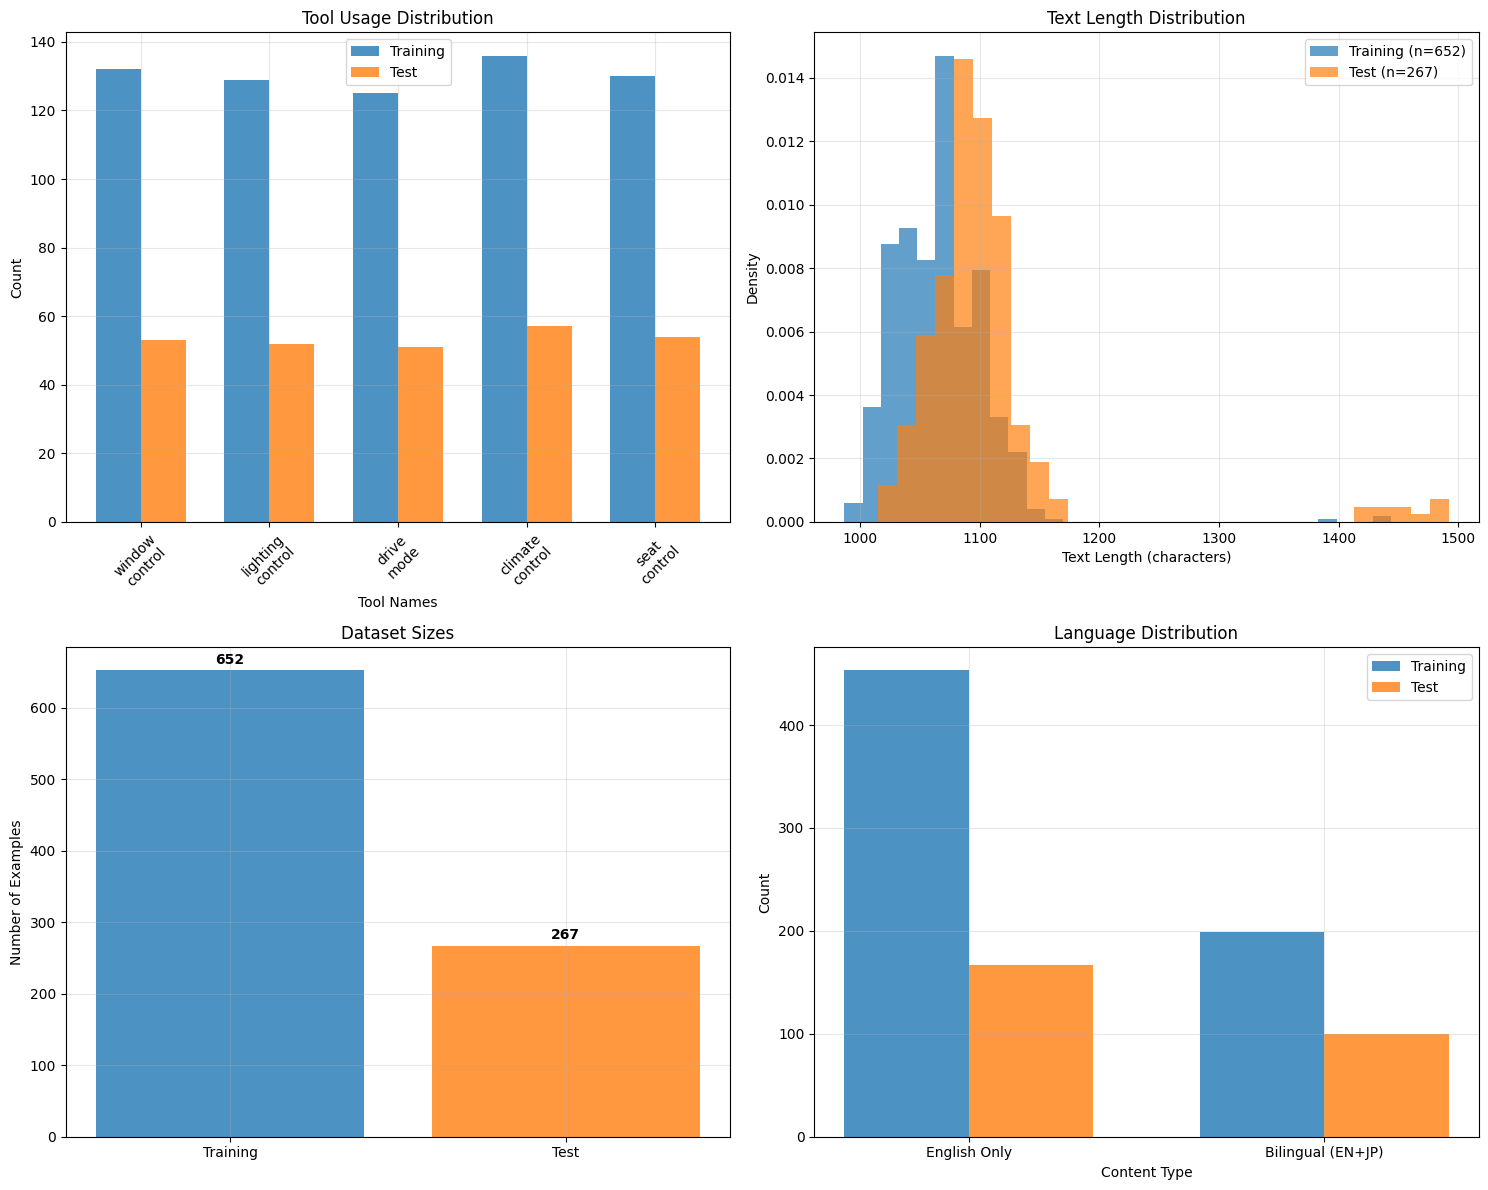

Training: 652 examples, 199 bilingual (30.5%)
Test: 267 examples, 100 bilingual (37.5%)
Avg text length - Training: 1066 chars, Test: 1105 chars


In [30]:
# Exploratory Data Analysis of Training and Test Datasets
import matplotlib.pyplot as plt
import re
from collections import Counter

# Extract tool usage and text lengths from datasets
def analyze_dataset(texts, dataset_name):
    tool_counts = Counter()
    text_lengths = []
    bilingual_count = 0
    
    for text in texts:
        # Count tool usage
        tool_match = re.search(r'"name":\s*"([^"]+)"', text)
        if tool_match:
            tool_counts[tool_match.group(1)] += 1
        
        # Text length analysis
        text_lengths.append(len(text))
        
        # Check for Japanese/bilingual content
        if any(ord(char) > 127 for char in text):
            bilingual_count += 1
    
    return tool_counts, text_lengths, bilingual_count

# Analyze both datasets
train_tools, train_lengths, train_bilingual = analyze_dataset(train_texts, "Training")
test_tools, test_lengths, test_bilingual = analyze_dataset(test_texts, "Test")

# Create 4 EDA charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Chart 1: Tool Distribution Comparison
tools = list(set(train_tools.keys()) | set(test_tools.keys()))
train_counts = [train_tools.get(tool, 0) for tool in tools]
test_counts = [test_tools.get(tool, 0) for tool in tools]

x = range(len(tools))
width = 0.35
ax1.bar([i - width/2 for i in x], train_counts, width, label='Training', alpha=0.8)
ax1.bar([i + width/2 for i in x], test_counts, width, label='Test', alpha=0.8)
ax1.set_xlabel('Tool Names')
ax1.set_ylabel('Count')
ax1.set_title('Tool Usage Distribution')
ax1.set_xticks(x)
ax1.set_xticklabels([tool.replace('_', '\n') for tool in tools], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Text Length Distribution
ax2.hist(train_lengths, bins=30, alpha=0.7, label=f'Training (n={len(train_texts)})', density=True)
ax2.hist(test_lengths, bins=30, alpha=0.7, label=f'Test (n={len(test_texts)})', density=True)
ax2.set_xlabel('Text Length (characters)')
ax2.set_ylabel('Density')
ax2.set_title('Text Length Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Chart 3: Dataset Size Comparison
datasets = ['Training', 'Test']
sizes = [len(train_texts), len(test_texts)]
colors = ['#1f77b4', '#ff7f0e']
bars = ax3.bar(datasets, sizes, color=colors, alpha=0.8)
ax3.set_ylabel('Number of Examples')
ax3.set_title('Dataset Sizes')
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{size:,}', ha='center', va='bottom', fontweight='bold')

# Chart 4: Bilingual Content Analysis
bilingual_data = [
    ['English Only', 'Bilingual (EN+JP)'],
    [len(train_texts) - train_bilingual, train_bilingual],
    [len(test_texts) - test_bilingual, test_bilingual]
]

x = range(len(bilingual_data[0]))
width = 0.35
ax4.bar([i - width/2 for i in x], bilingual_data[1], width, label='Training', alpha=0.8)
ax4.bar([i + width/2 for i in x], bilingual_data[2], width, label='Test', alpha=0.8)
ax4.set_xlabel('Content Type')
ax4.set_ylabel('Count')
ax4.set_title('Language Distribution')
ax4.set_xticks(x)
ax4.set_xticklabels(bilingual_data[0])
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Training: {len(train_texts):,} examples, {train_bilingual} bilingual ({train_bilingual/len(train_texts)*100:.1f}%)")
print(f"Test: {len(test_texts):,} examples, {test_bilingual} bilingual ({test_bilingual/len(test_texts)*100:.1f}%)")
print(f"Avg text length - Training: {sum(train_lengths)/len(train_lengths):.0f} chars, Test: {sum(test_lengths)/len(test_lengths):.0f} chars")

## Model Setup

In [31]:
# Load base model
model_name = "Qwen/Qwen3-1.7B"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B parameters")

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.34it/s]


Model loaded: 1.72B parameters


In [32]:
# Configure LoRA
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
model.enable_input_require_grads()

trainable params: 17,432,576 || all params: 1,738,007,552 || trainable%: 1.0030


## Training

In [33]:
# Prepare datasets
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=1024
    )

train_dataset = Dataset.from_dict({"text": train_texts})
test_dataset = Dataset.from_dict({"text": test_texts})

tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_test = test_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

Map: 100%|██████████| 267/267 [00:00<00:00, 2344.57 examples/s]


In [34]:
# Training configuration
training_args = TrainingArguments(
    output_dir="./qwen3-function-calling",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_steps=100,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=2e-4,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
)

/tmp/ipykernel_789861/3257573518.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [35]:
# Train the model
trainer.train()
trainer.save_model("./qwen3-function-calling-final")
tokenizer.save_pretrained("./qwen3-function-calling-final")

Epoch,Training Loss,Validation Loss
1,0.974900,0.634028
2,0.161000,0.271120
3,0.129000,0.248058


('./qwen3-function-calling-final/tokenizer_config.json',
 './qwen3-function-calling-final/special_tokens_map.json',
 './qwen3-function-calling-final/chat_template.jinja',
 './qwen3-function-calling-final/vocab.json',
 './qwen3-function-calling-final/merges.txt',
 './qwen3-function-calling-final/added_tokens.json',
 './qwen3-function-calling-final/tokenizer.json')

## Training Results

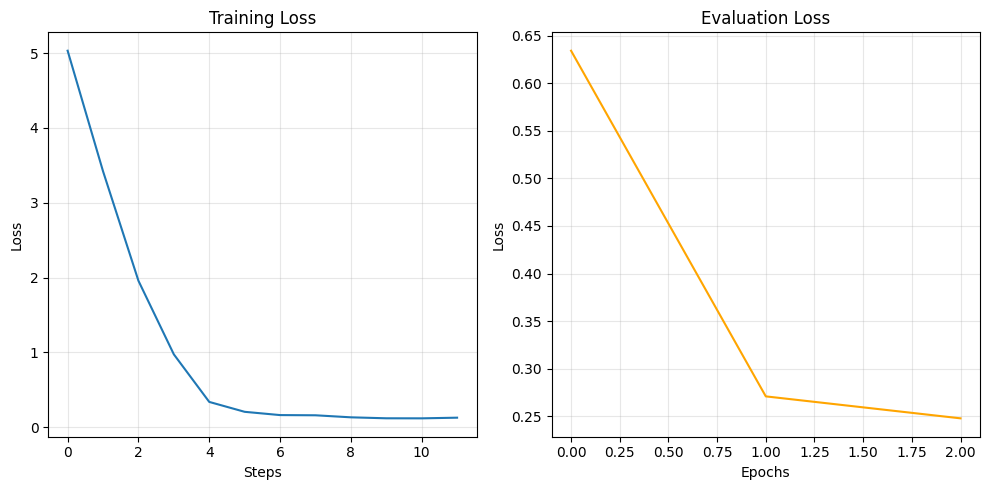

In [41]:
# Display training metrics
import matplotlib.pyplot as plt

# Extract loss from training history
train_loss = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

# Create loss plot
if train_loss or eval_loss:
    plt.figure(figsize=(10, 5))
    
    if train_loss:
        plt.subplot(1, 2, 1)
        plt.plot(train_loss)
        plt.title('Training Loss')
        plt.xlabel('Steps')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
    
    if eval_loss:
        plt.subplot(1, 2, 2)
        plt.plot(eval_loss, 'orange')
        plt.title('Evaluation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Export Model

In [42]:
# Merge LoRA weights and save
merged_model = model.merge_and_unload()
merged_model.save_pretrained("./qwen3-function-calling-merged")

In [44]:
# Copy common tokenizer files from final to merged model
import shutil
from pathlib import Path

# Define source and destination directories
source_dir = Path("./qwen3-function-calling-final")
dest_dir = Path("./qwen3-function-calling-merged")

# Common files that need to be copied
common_files = [
    "tokenizer.json",
    "tokenizer_config.json", 
    "vocab.json",
    "merges.txt",
    "special_tokens_map.json"
]

print("Copying common tokenizer files...")
for file_name in common_files:
    source_file = source_dir / file_name
    dest_file = dest_dir / file_name
    
    if source_file.exists():
        shutil.copy2(source_file, dest_file)
        print(f"✓ Copied {file_name}")
    else:
        print(f"✗ Source file not found: {file_name}")

print("\nTokenizer files synchronized between final and merged models.")


Copying common tokenizer files...
✓ Copied tokenizer.json
✓ Copied tokenizer_config.json
✓ Copied vocab.json
✓ Copied merges.txt
✓ Copied special_tokens_map.json

Tokenizer files synchronized between final and merged models.


## Convert Model to GGUF Format

Convert the merged model to GGUF format for efficient edge deployment. GGUF (GPT-Generated Unified Format) is optimized for inference with llama.cpp, providing:

- **Quantization**: Reduce model size by 75% with minimal quality loss
- **Fast Loading**: Memory-mapped files for instant model loading
- **Cross-Platform**: Works on CPU, GPU, and edge devices
- **Production Ready**: Battle-tested inference engine

In [1]:
import subprocess
import os
import shutil
from pathlib import Path

def convert_model_to_gguf(model_path, output_name="qwen3-finetuned.gguf", quantization="Q4_K_M", source_tokenizer_dir=None):
    """
    Convert the fine-tuned model to GGUF format for llama.cpp deployment.
    
    Args:
        model_path (str): Path to the merged model directory
        output_name (str): Name for the output GGUF file
        quantization (str): Quantization level (Q4_K_M, Q5_K_M, Q8_0, etc.)
        source_tokenizer_dir (str): Optional path to directory containing tokenizer files
                                   If None, will try to find them automatically
    
    Returns:
        str: Path to the created GGUF file, or None if failed
    """
    
    model_dir = Path(model_path)
    # Create a new directory for the GGUF file
    gguf_dir = model_dir.with_name(model_dir.name + "-gguf")
    gguf_dir.mkdir(parents=True, exist_ok=True)
    gguf_path = gguf_dir / output_name
    
    print(f"🔄 Converting model to GGUF format...")
    print(f"   Source: {model_path}")
    print(f"   Target: {gguf_path}")
    print(f"   Quantization: {quantization}")
    
    # Step 0: Ensure tokenizer files are present
    required_tokenizer_files = ["tokenizer.json", "vocab.json", "tokenizer_config.json"]
    missing_files = []
    
    for file in required_tokenizer_files:
        if not (model_dir / file).exists():
            missing_files.append(file)
    
    if missing_files:
        print(f"⚠️  Missing tokenizer files: {missing_files}")
        
        # Try to find tokenizer files automatically
        if source_tokenizer_dir is None:
            # Look for common directories that might contain tokenizer files
            possible_dirs = [
                model_dir.parent / "qwen3-function-calling-final",
                model_dir.parent / "qwen3-function-calling" / "checkpoint-123",
                model_dir.parent / "qwen3-function-calling" / "checkpoint-82"
            ]
            
            for dir_path in possible_dirs:
                if dir_path.exists():
                    # Check if this directory has all required tokenizer files
                    has_all_files = all((dir_path / file).exists() for file in required_tokenizer_files)
                    if has_all_files:
                        source_tokenizer_dir = str(dir_path)
                        print(f"🔍 Found tokenizer files in: {source_tokenizer_dir}")
                        break
        
        if source_tokenizer_dir and Path(source_tokenizer_dir).exists():
            print(f"📋 Copying tokenizer files from: {source_tokenizer_dir}")
            source_dir = Path(source_tokenizer_dir)
            
            # Copy missing tokenizer files
            for file in missing_files:
                source_file = source_dir / file
                target_file = model_dir / file
                
                if source_file.exists():
                    shutil.copy2(source_file, target_file)
                    print(f"   ✅ Copied: {file}")
                else:
                    print(f"   ❌ Missing in source: {file}")
            
            # Verify all files are now present
            still_missing = [f for f in required_tokenizer_files if not (model_dir / f).exists()]
            if still_missing:
                print(f"❌ Still missing tokenizer files: {still_missing}")
                print("   Please ensure tokenizer files are available in the model directory.")
                return None
            else:
                print("✅ All tokenizer files are now present!")
        else:
            print("❌ Could not find tokenizer files automatically.")
            print("   Please provide source_tokenizer_dir parameter or copy files manually.")
            print("   Required files: tokenizer.json, vocab.json, tokenizer_config.json")
            return None
    
    # Check if llama.cpp conversion tools are available
    convert_script = None
    quantize_binary = None
    
    # Look for conversion script (prioritize Homebrew installation)
    possible_convert_paths = [
        "./llama.cpp/convert_hf_to_gguf.py"
    ]
    
    for path in possible_convert_paths:
        if os.path.exists(path):
            convert_script = path
            break
    
    # Look for quantization binary (prioritize Homebrew installation)
    possible_quantize_paths = [
        "./llama.cpp/build/bin/llama-quantize"
    ]
    
    for path in possible_quantize_paths:
        if os.path.exists(path):
            quantize_binary = path
            break
    
    if not convert_script:
        print("❌ llama.cpp convert script not found.")
        print("   Please install llama.cpp and ensure convert.py is available.")
        print("   Installation: git clone https://github.com/ggerganov/llama.cpp && cd llama.cpp && make")
        return None
    
    try:
        # Step 1: Convert to FP16 GGUF
        temp_gguf = gguf_dir / f"temp_{output_name}"
        
        convert_cmd = ["uv", "run", convert_script, str(model_path), "--outfile", str(temp_gguf), "--outtype", "f16" ]
        print(f"🔧 Step 1: Converting to FP16 GGUF...")
        print(f"   Command: {' '.join(convert_cmd)}")
        
        result = subprocess.run(convert_cmd, capture_output=True, text=True, check=True)
        print(f"✅ FP16 conversion successful!")
        
        # Step 2: Quantize if requested and quantize binary is available
        if quantization != "F16" and quantize_binary:
            print(f"🔧 Step 2: Quantizing to {quantization}...")
            
            quantize_cmd = [quantize_binary, str(temp_gguf), str(gguf_path), quantization]
            print(f"   Command: {' '.join(quantize_cmd)}")
            
            result = subprocess.run(quantize_cmd, capture_output=True, text=True, check=True)
            print(f"✅ Quantization to {quantization} successful!")
            
            # Remove temporary file
            temp_gguf.unlink()
            
        else:
            # Just rename the FP16 file
            temp_gguf.rename(gguf_path)
            if quantization != "F16":
                print(f"⚠️  Quantization binary not found, keeping FP16 format")
        
        # Verify the output file
        if gguf_path.exists():
            file_size = gguf_path.stat().st_size / (1024**3)  # Size in GB
            print(f"✅ GGUF conversion completed!")
            print(f"📁 Output file: {gguf_path}")
            print(f"📊 File size: {file_size:.2f} GB")
            print(f"🎯 Ready for llama.cpp deployment!")
            
            return str(gguf_path)
        else:
            print(f"❌ Output file not created: {gguf_path}")
            return None
            
    except subprocess.CalledProcessError as e:
        print(f"❌ Conversion failed: {e}")
        print(f"Error output: {e.stderr}")
        
        # Clean up temp file if it exists
        if 'temp_gguf' in locals() and temp_gguf.exists():
            temp_gguf.unlink()
        
        return None
    except Exception as e:
        print(f"❌ Conversion error: {e}")
        return None

# Convert the merged model to GGUF
MODEL_NAME = "qwen3-function-calling-v1"
QUANTIZATION = "Q4_K_M"  # Good balance of size and quality

print(f"🚀 Converting fine-tuned model to GGUF format")
print(f"📝 Model: {MODEL_NAME}")
print(f"⚙️  Quantization: {QUANTIZATION}")

gguf_file_path = convert_model_to_gguf(
    model_path="./qwen3-function-calling-merged",
    output_name=f"{MODEL_NAME}-{QUANTIZATION}.gguf",
    quantization=QUANTIZATION,
    source_tokenizer_dir="./qwen3-function-calling-final"
)

if gguf_file_path:
    print(f"\n✅ SUCCESS! Model converted to GGUF format.")
    print(f"📁 GGUF file: {gguf_file_path}")
    print(f"🔄 Next: Upload this GGUF file to S3 for deployment")
    
    # Store for next steps
    GGUF_MODEL_PATH = gguf_file_path
else:
    print(f"❌ GGUF conversion failed. Please check llama.cpp installation.")
    GGUF_MODEL_PATH = None

🚀 Converting fine-tuned model to GGUF format
📝 Model: qwen3-function-calling-v1
⚙️  Quantization: Q4_K_M
🔄 Converting model to GGUF format...
   Source: ./qwen3-function-calling-merged
   Target: qwen3-function-calling-merged-gguf/qwen3-function-calling-v1-Q4_K_M.gguf
   Quantization: Q4_K_M
🔧 Step 1: Converting to FP16 GGUF...
   Command: uv run ./llama.cpp/convert_hf_to_gguf.py ./qwen3-function-calling-merged --outfile qwen3-function-calling-merged-gguf/temp_qwen3-function-calling-v1-Q4_K_M.gguf --outtype f16
✅ FP16 conversion successful!
🔧 Step 2: Quantizing to Q4_K_M...
   Command: ./llama.cpp/build/bin/llama-quantize qwen3-function-calling-merged-gguf/temp_qwen3-function-calling-v1-Q4_K_M.gguf qwen3-function-calling-merged-gguf/qwen3-function-calling-v1-Q4_K_M.gguf Q4_K_M
✅ Quantization to Q4_K_M successful!
✅ GGUF conversion completed!
📁 Output file: qwen3-function-calling-merged-gguf/qwen3-function-calling-v1-Q4_K_M.gguf
📊 File size: 1.03 GB
🎯 Ready for llama.cpp deployment!

✅ 

## Comprehensive Model Evaluation

Compare raw base model vs fine-tuned model vs GGUF quantized model on:
- Tool calling accuracy
- Inference speed
- Memory usage
- Response quality

In [23]:
import time
import json
import re
import requests
import subprocess
import signal
import psutil
from pathlib import Path

# Test cases for evaluation
TEST_CASES = [
    {
        "prompt": "Set the temperature to 72 degrees",
        "expected_tool": "climate_control",
        "expected_args": {"command": "set temperature to 72 degrees"}
    },
    {
        "prompt": "Open the driver side window", 
        "expected_tool": "window_control",
        "expected_args": {"command": "open driver window"}
    },
    {
        "prompt": "Switch to sport mode",
        "expected_tool": "drive_mode", 
        "expected_args": {"command": "switch to sport mode"}
    },
    {
        "prompt": "Turn on the headlights",
        "expected_tool": "lighting_control",
        "expected_args": {"command": "turn on headlights"}
    },
    {
        "prompt": "Move seat forward",
        "expected_tool": "seat_control",
        "expected_args": {"command": "move seat forward"}
    }
]

def create_test_prompt(user_message):
    """Create properly formatted test prompt."""
    return f"""<|im_start|>system
# Tools

You may call one or more functions to assist with the user query.

You are provided with function signatures within <tools></tools> XML tags:
<tools>
{{"name": "climate_control", "description": "Control vehicle climate settings", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Climate Control command"}}}}, "required": ["command"]}}}}}}
{{"name": "window_control", "description": "Control vehicle windows", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Window control command"}}}}, "required": ["command"]}}}}}}
{{"name": "drive_mode", "description": "Change vehicle drive mode", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Drive mode command"}}}}, "required": ["command"]}}}}}}
{{"name": "lighting_control", "description": "Control vehicle lighting", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Lighting control command"}}}}, "required": ["command"]}}}}}}
{{"name": "seat_control", "description": "Control vehicle seats", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Seat control command"}}}}, "required": ["command"]}}}}}}
</tools>

For each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:
<tool_call>
{{"name": <function-name>, "arguments": <args-json-object>}}
</tool_call><|im_end|>
<|im_start|>user
{user_message}
<|im_end|>
<|im_start|>assistant
"""

def extract_tool_call(response):
    """Extract tool call from model response."""
    try:
        # Find tool_call tags
        match = re.search(r'<tool_call>(.*?)</tool_call>', response, re.DOTALL)
        if not match:
            return None, None
        
        # Parse JSON
        tool_json = json.loads(match.group(1).strip())
        return tool_json.get('name'), tool_json.get('arguments')
    except:
        return None, None

def measure_memory_usage():
    """Get current memory usage in MB."""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

print("✅ Evaluation functions loaded")

✅ Evaluation functions loaded


In [24]:
def evaluate_raw_model():
    """Evaluate the raw base model performance."""
    print("🔄 Loading raw base model...")
    start_mem = measure_memory_usage()
    
    # Load raw base model
    base_model = AutoModelForCausalLM.from_pretrained(
        "Qwen/Qwen3-1.7B",
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True
    )
    base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-1.7B", trust_remote_code=True)
    if base_tokenizer.pad_token is None:
        base_tokenizer.pad_token = base_tokenizer.eos_token
    
    load_mem = measure_memory_usage()
    
    results = {
        "model_type": "Raw Base Model",
        "memory_usage_mb": load_mem - start_mem,
        "test_results": [],
        "total_time": 0,
        "accuracy": 0
    }
    
    base_model.eval()
    correct_predictions = 0
    total_time = 0
    
    for i, test_case in enumerate(TEST_CASES):
        prompt = create_test_prompt(test_case["prompt"])
        
        # Tokenize
        inputs = base_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
        inputs = {k: v.to(base_model.device) for k, v in inputs.items()}
        
        # Time inference
        start_time = time.time()
        with torch.no_grad():
            outputs = base_model.generate(
                **inputs,
                max_new_tokens=200,
                temperature=0.1,  # Lower temperature for more consistent results
                do_sample=True,
                pad_token_id=base_tokenizer.pad_token_id
            )
        inference_time = time.time() - start_time
        total_time += inference_time
        
        # Decode response
        response = base_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False)
        
        # Extract tool call
        tool_name, tool_args = extract_tool_call(response)
        
        # Check accuracy
        is_correct = tool_name == test_case["expected_tool"]
        if is_correct:
            correct_predictions += 1
        
        results["test_results"].append({
            "test_case": test_case["prompt"],
            "expected_tool": test_case["expected_tool"],
            "predicted_tool": tool_name,
            "correct": is_correct,
            "inference_time_ms": inference_time * 1000,
            "response": response[:200] + "..." if len(response) > 200 else response,
            "full_response": response  # Store full response for debugging
        })
        
        print(f"  Test {i+1}/5: {'✓' if is_correct else '✗'} {test_case['prompt'][:30]}... ({inference_time*1000:.0f}ms)")
        if not is_correct:
            print(f"    Expected: {test_case['expected_tool']}")
            print(f"    Got: {tool_name or 'None'}")
            print(f"    Raw output: {response[:150]}{'...' if len(response) > 150 else ''}")
            print()
    
    results["accuracy"] = correct_predictions / len(TEST_CASES)
    results["total_time"] = total_time
    results["avg_time_ms"] = (total_time / len(TEST_CASES)) * 1000
    
    # Clean up
    del base_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return results

def evaluate_finetuned_model():
    """Evaluate the fine-tuned model performance."""
    print("🔄 Loading fine-tuned model...")
    start_mem = measure_memory_usage()
    
    # Load fine-tuned model
    ft_model = AutoModelForCausalLM.from_pretrained(
        "Qwen/Qwen3-1.7B",
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True
    )
    ft_model = PeftModel.from_pretrained(ft_model, "./qwen3-function-calling-final")
    ft_tokenizer = AutoTokenizer.from_pretrained("./qwen3-function-calling-final", trust_remote_code=True)
    if ft_tokenizer.pad_token is None:
        ft_tokenizer.pad_token = ft_tokenizer.eos_token
    
    load_mem = measure_memory_usage()
    
    results = {
        "model_type": "Fine-tuned Model",
        "memory_usage_mb": load_mem - start_mem,
        "test_results": [],
        "total_time": 0,
        "accuracy": 0
    }
    
    ft_model.eval()
    correct_predictions = 0
    total_time = 0
    
    for i, test_case in enumerate(TEST_CASES):
        prompt = create_test_prompt(test_case["prompt"])
        
        # Tokenize
        inputs = ft_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
        inputs = {k: v.to(ft_model.device) for k, v in inputs.items()}
        
        # Time inference
        start_time = time.time()
        with torch.no_grad():
            outputs = ft_model.generate(
                **inputs,
                max_new_tokens=200,
                temperature=0.1,
                do_sample=True,
                pad_token_id=ft_tokenizer.pad_token_id
            )
        inference_time = time.time() - start_time
        total_time += inference_time
        
        # Decode response
        response = ft_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False)
        
        # Extract tool call
        tool_name, tool_args = extract_tool_call(response)
        
        # Check accuracy
        is_correct = tool_name == test_case["expected_tool"]
        if is_correct:
            correct_predictions += 1
        
        results["test_results"].append({
            "test_case": test_case["prompt"],
            "expected_tool": test_case["expected_tool"],
            "predicted_tool": tool_name,
            "correct": is_correct,
            "inference_time_ms": inference_time * 1000,
            "response": response[:200] + "..." if len(response) > 200 else response,
            "full_response": response  # Store full response for debugging
        })
        
        print(f"  Test {i+1}/5: {'✓' if is_correct else '✗'} {test_case['prompt'][:30]}... ({inference_time*1000:.0f}ms)")
        if not is_correct:
            print(f"    Expected: {test_case['expected_tool']}")
            print(f"    Got: {tool_name or 'None'}")
            print(f"    Raw output: {response[:150]}{'...' if len(response) > 150 else ''}")
            print()
    
    results["accuracy"] = correct_predictions / len(TEST_CASES)
    results["total_time"] = total_time
    results["avg_time_ms"] = (total_time / len(TEST_CASES)) * 1000
    
    # Clean up
    del ft_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return results

print("✅ Model evaluation functions loaded")

✅ Model evaluation functions loaded


In [27]:
# GGUF Server Management and Evaluation
import sys
import requests
import subprocess
import signal
import os
import threading
from pathlib import Path

class GGUFServerManager:
    """Manage llama.cpp server for GGUF model evaluation."""
    
    def __init__(self, gguf_path="./qwen3-finetuned.gguf", port=8080):
        self.gguf_path = gguf_path
        self.port = port
        self.process = None
        self.server_ready = False
    
    def start_server(self):
        """Start llama.cpp server in background."""
        if not Path(self.gguf_path).exists():
            print(f"❌ GGUF file not found: {self.gguf_path}")
            return False
        
        # Check if llama-server exists
        llama_server_path = "./llama.cpp/build/bin/llama-server"
        if not Path(llama_server_path).exists():
            print(f"❌ llama-server not found at {llama_server_path}")
            return False
        
        print(f"🚀 Starting GGUF server on port {self.port}...")
        
        # Start server process
        cmd = [
            llama_server_path,
            "-m", self.gguf_path,
            "--host", "0.0.0.0",
            "--port", str(self.port),
            "-c", "2048",
            "--jinja"
        ]
        
        try:
            self.process = subprocess.Popen(
                cmd,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True
            )

            time.sleep(30)
            
            # Wait for server to be ready
            for i in range(30):  # Wait up to 30 seconds
                time.sleep(1)
                if self.check_server():
                    self.server_ready = True
                    print(f"✅ GGUF server ready on port {self.port}")
                    return True
                print(f"  Waiting for server... ({i+1}/30)")
            
            print("❌ Server failed to start within 30 seconds")
            self.stop_server()
            return False
            
        except Exception as e:
            print(f"❌ Failed to start server: {e}")
            return False
    
    def check_server(self):
        """Check if server is responding."""
        try:
            response = requests.get(f"http://localhost:{self.port}/health", timeout=2)
            return response.status_code == 200
        except:
            return False
    
    def stop_server(self):
        """Stop the server process."""
        if self.process:
            print(f"🛑 Stopping GGUF server...")
            self.process.terminate()
            try:
                self.process.wait(timeout=5)
            except subprocess.TimeoutExpired:
                self.process.kill()
            self.process = None
            self.server_ready = False
    
    def __enter__(self):
        self.start_server()
        return self
    
    def __exit__(self, exc_type, exc_val, exc_tb):
        self.stop_server()

def evaluate_gguf_model(port=8080):
    """Evaluate GGUF model via llama.cpp server."""
    print("🔄 Testing GGUF model via server...")
    
    if not requests.get(f"http://localhost:{port}/health", timeout=2).status_code == 200:
        print(f"❌ Server not responding on port {port}")
        return None
    
    results = {
        "model_type": "GGUF Quantized Model",
        "memory_usage_mb": "N/A (External Process)",
        "test_results": [],
        "total_time": 0,
        "accuracy": 0
    }
    
    correct_predictions = 0
    total_time = 0
    
    for i, test_case in enumerate(TEST_CASES):
        prompt = create_test_prompt(test_case["prompt"])
        
        # Prepare request
        payload = {
            "prompt": prompt,
            "max_tokens": 200,
            "temperature": 0.1,
            # "stop": ["<|im_end|>"]
        }
        
        # Time inference
        start_time = time.time()
        try:
            response = requests.post(
                f"http://localhost:{port}/completion",
                json=payload,
                timeout=30
            )
            response.raise_for_status()
            result = response.json()
            inference_time = time.time() - start_time
            total_time += inference_time
            
            # Extract response text
            response_text = result.get("content", "")
            
        except Exception as e:
            print(f"  ❌ Request failed: {e}")
            inference_time = 0
            response_text = ""
        
        # Extract tool call
        tool_name, tool_args = extract_tool_call(response_text)
        
        # Check accuracy
        is_correct = tool_name == test_case["expected_tool"]
        if is_correct:
            correct_predictions += 1
        
        results["test_results"].append({
            "test_case": test_case["prompt"],
            "expected_tool": test_case["expected_tool"],
            "predicted_tool": tool_name,
            "correct": is_correct,
            "inference_time_ms": inference_time * 1000,
            "response": response_text[:200] + "..." if len(response_text) > 200 else response_text,
            "full_response": response_text  # Store full response for debugging
        })
        
        print(f"  Test {i+1}/5: {'✓' if is_correct else '✗'} {test_case['prompt'][:30]}... ({inference_time*1000:.0f}ms)")
        if not is_correct:
            print(f"    Expected: {test_case['expected_tool']}")
            print(f"    Got: {tool_name or 'None'}")
            print(f"    Raw output: {response_text[:150]}{'...' if len(response_text) > 150 else ''}")
            print()
    
    results["accuracy"] = correct_predictions / len(TEST_CASES)
    results["total_time"] = total_time
    results["avg_time_ms"] = (total_time / len(TEST_CASES)) * 1000
    
    return results

print("✅ GGUF evaluation functions loaded")

✅ GGUF evaluation functions loaded


In [28]:
def run_comprehensive_evaluation():
    """Run comprehensive evaluation comparing all model types."""
    print("🚀 Starting Comprehensive Model Evaluation")
    print("=" * 60)
    
    all_results = []
    
    # 1. Evaluate Raw Base Model
    print("\n📊 EVALUATING RAW BASE MODEL")
    print("-" * 40)
    try:
        raw_results = evaluate_raw_model()
        all_results.append(raw_results)
        print(f"✅ Raw model evaluation complete: {raw_results['accuracy']:.1%} accuracy")
    except Exception as e:
        print(f"❌ Raw model evaluation failed: {e}")
        raw_results = None
    
    # 2. Evaluate Fine-tuned Model
    print("\n📊 EVALUATING FINE-TUNED MODEL")
    print("-" * 40)
    try:
        ft_results = evaluate_finetuned_model()
        all_results.append(ft_results)
        print(f"✅ Fine-tuned model evaluation complete: {ft_results['accuracy']:.1%} accuracy")
    except Exception as e:
        print(f"❌ Fine-tuned model evaluation failed: {e}")
        ft_results = None
    
    # 3. Evaluate GGUF Model (with server management)
    print("\n📊 EVALUATING GGUF QUANTIZED MODEL")
    print("-" * 40)
    gguf_results = None
    
    # Check if GGUF file exists
    if Path("./qwen3-function-calling-merged-gguf/qwen3-function-calling-v1-Q4_K_M.gguf").exists():
        try:
            with GGUFServerManager("./qwen3-function-calling-merged-gguf/qwen3-function-calling-v1-Q4_K_M.gguf", 8080) as server:
                if server.server_ready:
                    gguf_results = evaluate_gguf_model(8080)
                    all_results.append(gguf_results)
                    print(f"✅ GGUF model evaluation complete: {gguf_results['accuracy']:.1%} accuracy")
                else:
                    print("❌ GGUF server failed to start")
        except Exception as e:
            print(f"❌ GGUF model evaluation failed: {e}")
    else:
        print("⚠️  GGUF file not found, skipping GGUF evaluation")
    
    # 4. Generate Comparison Report
    print("\n" + "=" * 60)
    print("📈 COMPREHENSIVE EVALUATION RESULTS")
    print("=" * 60)
    
    if not all_results:
        print("❌ No successful evaluations to compare")
        return
    
    # Summary table
    print(f"{'Model Type':<25} {'Accuracy':<10} {'Avg Time (ms)':<15} {'Memory (MB)':<12}")
    print("-" * 70)
    
    for result in all_results:
        model_type = result['model_type']
        accuracy = f"{result['accuracy']:.1%}"
        avg_time = f"{result['avg_time_ms']:.0f}ms"
        memory = f"{result['memory_usage_mb']:.0f}" if isinstance(result['memory_usage_mb'], (int, float)) else str(result['memory_usage_mb'])
        
        print(f"{model_type:<25} {accuracy:<10} {avg_time:<15} {memory:<12}")
    
    # Detailed comparison
    print("\n📋 DETAILED TEST RESULTS")
    print("-" * 40)
    
    for i, test_case in enumerate(TEST_CASES):
        print(f"\nTest {i+1}: {test_case['prompt']}")
        print(f"Expected: {test_case['expected_tool']}")
        
        for result in all_results:
            test_result = result['test_results'][i]
            status = "✓" if test_result['correct'] else "✗"
            predicted = test_result['predicted_tool'] or "None"
            time_ms = test_result['inference_time_ms']
            
            print(f"  {result['model_type']:<25} {status} {predicted:<15} ({time_ms:.0f}ms)")
    
    # Performance insights
    print("\n🎯 KEY INSIGHTS")
    print("-" * 40)
    
    if len(all_results) >= 2:
        # Compare accuracy improvements
        if raw_results and ft_results:
            accuracy_improvement = (ft_results['accuracy'] - raw_results['accuracy']) * 100
            print(f"📈 Fine-tuning accuracy improvement: +{accuracy_improvement:.1f} percentage points")
        
        # Compare speed
        if ft_results and gguf_results:
            speed_ratio = ft_results['avg_time_ms'] / gguf_results['avg_time_ms']
            print(f"⚡ GGUF speed improvement: {speed_ratio:.1f}x faster than fine-tuned model")
        
        # Memory efficiency
        if ft_results:
            print(f"💾 Fine-tuned model memory usage: {ft_results['memory_usage_mb']:.0f} MB")
        
        print(f"🎯 Best accuracy: {max(r['accuracy'] for r in all_results):.1%}")
        print(f"⚡ Fastest inference: {min(r['avg_time_ms'] for r in all_results):.0f}ms average")
    
    # 5. Detailed Error Analysis
    print("\n" + "=" * 60)
    print("🔍 DETAILED ERROR ANALYSIS")
    print("=" * 60)
    
    for i, test_case in enumerate(TEST_CASES):
        print(f"\n📝 Test {i+1}: {test_case['prompt']}")
        print(f"Expected Tool: {test_case['expected_tool']}")
        print("-" * 40)
        
        for result in all_results:
            test_result = result['test_results'][i]
            status = "✅ CORRECT" if test_result['correct'] else "❌ INCORRECT"
            predicted = test_result['predicted_tool'] or "None"
            
            print(f"\n{result['model_type']}:")
            print(f"  Status: {status}")
            print(f"  Predicted: {predicted}")
            print(f"  Time: {test_result['inference_time_ms']:.0f}ms")
            
            if not test_result['correct']:
                # Show raw output for failed cases
                raw_output = test_result.get('full_response', test_result['response'])
                print(f"  Raw Output: {raw_output[:200]}{'...' if len(raw_output) > 200 else ''}")
    
    print("\n✅ Comprehensive evaluation complete!")
    return all_results

# Run the comprehensive evaluation
evaluation_results = run_comprehensive_evaluation()

🚀 Starting Comprehensive Model Evaluation

📊 EVALUATING RAW BASE MODEL
----------------------------------------
🔄 Loading raw base model...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.32it/s]


  Test 1/5: ✗ Set the temperature to 72 degr... (6665ms)
    Expected: climate_control
    Got: None
    Raw output: <think>
Okay, the user wants to set the temperature to 72 degrees. Let me check the available tools. There's the climate_control function, which is me...

  Test 2/5: ✓ Open the driver side window... (3890ms)
  Test 3/5: ✓ Switch to sport mode... (3325ms)
  Test 4/5: ✓ Turn on the headlights... (3472ms)
  Test 5/5: ✓ Move seat forward... (4031ms)
✅ Raw model evaluation complete: 80.0% accuracy

📊 EVALUATING FINE-TUNED MODEL
----------------------------------------
🔄 Loading fine-tuned model...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.32it/s]


  Test 1/5: ✗ Set the temperature to 72 degr... (709ms)
    Expected: climate_control
    Got: None
    Raw output: I'll set the temperature to 72 degrees.
<|im_end|>

  Test 2/5: ✗ Open the driver side window... (536ms)
    Expected: window_control
    Got: None
    Raw output: I'll open the driver side window.
<|im_end|>

  Test 3/5: ✗ Switch to sport mode... (479ms)
    Expected: drive_mode
    Got: None
    Raw output: I'll switch to sport mode.
<|im_end|>

  Test 4/5: ✗ Turn on the headlights... (479ms)
    Expected: lighting_control
    Got: None
    Raw output: I'll turn on the headlights.
<|im_end|>

  Test 5/5: ✗ Move seat forward... (494ms)
    Expected: seat_control
    Got: None
    Raw output: I'll move the seat forward.
<|im_end|>

✅ Fine-tuned model evaluation complete: 0.0% accuracy

📊 EVALUATING GGUF QUANTIZED MODEL
----------------------------------------
🚀 Starting GGUF server on port 8080...
✅ GGUF server ready on port 8080
🔄 Testing GGUF model via server...
  Test 

## Upload GGUF Model to S3

Upload the production-ready GGUF model to S3 for fast edge deployment.
GGUF files are optimized for edge inference and much smaller than full model directories.


In [ ]:
# Upload GGUF model to S3
import boto3
import os
from pathlib import Path
from botocore.exceptions import ClientError, NoCredentialsError

def upload_gguf_to_s3(bucket_name, gguf_file_path="./qwen3-finetuned.gguf", s3_prefix="gguf-models/"):
    """
    Upload GGUF model file to S3 bucket for edge deployment.
    
    Args:
        bucket_name: Name of the S3 bucket
        gguf_file_path: Path to the GGUF file
        s3_prefix: S3 key prefix (folder path)
    """
    try:
        # Initialize S3 client
        s3_client = boto3.client('s3')
        
        # Check if bucket exists and is accessible
        try:
            s3_client.head_bucket(Bucket=bucket_name)
            print(f"✓ S3 bucket '{bucket_name}' is accessible")
        except ClientError as e:
            error_code = e.response['Error']['Code']
            if error_code == '404':
                print(f"✗ Bucket '{bucket_name}' does not exist")
                return False
            else:
                print(f"✗ Cannot access bucket '{bucket_name}': {e}")
                return False
        
        local_path = Path(local_model_dir)
        if not local_path.exists():
            print(f"✗ Local model directory not found: {local_model_dir}")
            return False
        
        # Get list of files to upload
        model_files = list(local_path.glob("*"))
        if not model_files:
            print(f"✗ No files found in {local_model_dir}")
            return False
        
        print(f"Uploading {len(model_files)} files to s3://{bucket_name}/{s3_prefix}")
        
        uploaded_files = []
        for file_path in model_files:
            if file_path.is_file():
                s3_key = f"{s3_prefix}{file_path.name}"
                
                try:
                    # Upload file with progress
                    file_size = file_path.stat().st_size
                    print(f"  Uploading {file_path.name} ({file_size / 1024 / 1024:.1f} MB)...")
                    
                    s3_client.upload_file(
                        str(file_path), 
                        bucket_name, 
                        s3_key,
                        ExtraArgs={'ServerSideEncryption': 'AES256'}  # Enable encryption
                    )
                    
                    uploaded_files.append(s3_key)
                    print(f"    ✓ {s3_key}")
                    
                except Exception as e:
                    print(f"    ✗ Failed to upload {file_path.name}: {e}")
                    return False
        
        print(f"\n✓ Successfully uploaded {len(uploaded_files)} files to S3")
        print(f"  Bucket: {bucket_name}")
        print(f"  Prefix: {s3_prefix}")
        print(f"  Files: {', '.join([f.split('/')[-1] for f in uploaded_files])}")
        
        return True
        
    except NoCredentialsError:
        print("✗ AWS credentials not found. Please configure AWS credentials.")
        print("  Options:")
        print("  - AWS CLI: aws configure")
        print("  - Environment variables: AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY")
        print("  - IAM roles (if running on EC2)")
        return False
    except Exception as e:
        print(f"✗ Upload failed: {e}")
        return False

# Configuration - UPDATE THESE VALUES
S3_BUCKET_NAME = "test-fc-artifact"  # Replace with your bucket name
S3_MODEL_PREFIX = "model/"

# Upload the model
print("=" * 60)
print("UPLOADING MERGED MODEL TO S3")
print("=" * 60)

# Simple GGUF upload function
def upload_gguf_simple(bucket_name, gguf_file="./qwen3-finetuned.gguf", s3_key="gguf-models/qwen3-finetuned.gguf"):
    """Simple function to upload GGUF file to S3."""
    try:
        s3_client = boto3.client('s3')
        gguf_path = Path(gguf_file)
        
        if not gguf_path.exists():
            print(f"❌ GGUF file not found: {gguf_file}")
            return False
        
        file_size_mb = gguf_path.stat().st_size / 1024 / 1024
        print(f"📤 Uploading {gguf_path.name} ({file_size_mb:.1f} MB) to s3://{bucket_name}/{s3_key}")
        
        s3_client.upload_file(
            str(gguf_path),
            bucket_name,
            s3_key,
            ExtraArgs={'ServerSideEncryption': 'AES256'}
        )
        
        print(f"✅ Successfully uploaded GGUF model to S3")
        return True
        
    except Exception as e:
        print(f"❌ Upload failed: {e}")
        return False

# Update S3 configuration for GGUF
S3_GGUF_KEY = "gguf-models/qwen3-finetuned.gguf"

# Upload the GGUF model
print("=" * 60)
print("UPLOADING GGUF MODEL TO S3")
print("=" * 60)

success = upload_gguf_simple(S3_BUCKET_NAME, "./qwen3-finetuned.gguf", S3_GGUF_KEY)

if success:
    print(f"\n🎉 GGUF model successfully uploaded to s3://{S3_BUCKET_NAME}/{S3_GGUF_KEY}")
    print(f"📋 Model ready for edge deployment!")
    print(f"   Size: ~1.1GB (75% smaller than original)")
    print(f"   Format: Q4_K_M quantized GGUF")
    print(f"   Compatible with: llama.cpp, Ollama, LM Studio")
else:
    print(f"\n❌ Upload failed. Please check configuration and try again.")


In [ ]:
# Download model artifacts from S3 to test directory
import shutil

def download_model_from_s3(bucket_name, s3_prefix="model/", local_test_dir="./qwen3-downloaded-test"):
    """
    Download model artifacts from S3 to a local test directory.
    
    Args:
        bucket_name: Name of the S3 bucket
        s3_prefix: S3 key prefix (folder path)
        local_test_dir: Local directory to download files to
    """
    try:
        # Initialize S3 client
        s3_client = boto3.client('s3')
        
        # Create local test directory
        test_path = Path(local_test_dir)
        if test_path.exists():
            print(f"Removing existing test directory: {local_test_dir}")
            shutil.rmtree(test_path)
        
        test_path.mkdir(parents=True, exist_ok=True)
        print(f"✓ Created test directory: {local_test_dir}")
        
        # List objects in S3 with the specified prefix
        try:
            response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=s3_prefix)
            
            if 'Contents' not in response:
                print(f"✗ No files found in s3://{bucket_name}/{s3_prefix}")
                return False
            
            files_to_download = response['Contents']
            print(f"Found {len(files_to_download)} files to download")
            
        except ClientError as e:
            print(f"✗ Failed to list S3 objects: {e}")
            return False
        
        # Download each file
        downloaded_files = []
        total_size = 0
        
        for obj in files_to_download:
            s3_key = obj['Key']
            file_name = s3_key.replace(s3_prefix, '')  # Remove prefix to get filename
            
            if not file_name:  # Skip if it's just the prefix (directory)
                continue
                
            local_file_path = test_path / file_name
            file_size = obj['Size']
            
            try:
                print(f"  Downloading {file_name} ({file_size / 1024 / 1024:.1f} MB)...")
                
                s3_client.download_file(bucket_name, s3_key, str(local_file_path))
                
                downloaded_files.append(file_name)
                total_size += file_size
                print(f"    ✓ {file_name}")
                
            except Exception as e:
                print(f"    ✗ Failed to download {file_name}: {e}")
                return False
        
        print(f"\n✓ Successfully downloaded {len(downloaded_files)} files")
        print(f"  Total size: {total_size / 1024 / 1024:.1f} MB")
        print(f"  Location: {local_test_dir}")
        print(f"  Files: {', '.join(downloaded_files)}")
        
        return True
        
    except Exception as e:
        print(f"✗ Download failed: {e}")
        return False

# Download the model from S3
print("=" * 60)
print("DOWNLOADING MODEL FROM S3 FOR TESTING")
print("=" * 60)

download_success = download_model_from_s3(S3_BUCKET_NAME, S3_MODEL_PREFIX, "./qwen3-downloaded-test")

if download_success:
    print(f"\n🎉 Model successfully downloaded from s3://{S3_BUCKET_NAME}/{S3_MODEL_PREFIX}")
    
    # Verify downloaded files
    test_dir = Path("./qwen3-downloaded-test")
    downloaded_files = list(test_dir.glob("*"))
    print(f"\nDownloaded files verification:")
    for file_path in downloaded_files:
        if file_path.is_file():
            size_mb = file_path.stat().st_size / 1024 / 1024
            print(f"  ✓ {file_path.name} ({size_mb:.1f} MB)")
else:
    print(f"\n❌ Download failed. Please check S3 configuration and try again.")


In [ ]:
# Test the downloaded model copy
def test_downloaded_model(model_dir="./qwen3-downloaded-test"):
    """
    Test the downloaded model to verify it works correctly.
    
    Args:
        model_dir: Directory containing the downloaded model files
    """
    try:
        model_path = Path(model_dir)
        if not model_path.exists():
            print(f"✗ Model directory not found: {model_dir}")
            return False
        
        # Check required files
        required_files = ["config.json", "model.safetensors", "tokenizer.json"]
        missing_files = []
        
        for file_name in required_files:
            if not (model_path / file_name).exists():
                missing_files.append(file_name)
        
        if missing_files:
            print(f"✗ Missing required files: {', '.join(missing_files)}")
            return False
        
        print("✓ All required model files present")
        
        # Load the downloaded model
        print("Loading downloaded model...")
        
        test_model = AutoModelForCausalLM.from_pretrained(
            model_dir,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True,
            local_files_only=True  # Only use local files, no downloads
        )
        
        test_tokenizer = AutoTokenizer.from_pretrained(
            model_dir,
            trust_remote_code=True,
            local_files_only=True
        )
        
        if test_tokenizer.pad_token is None:
            test_tokenizer.pad_token = test_tokenizer.eos_token
        
        print("✓ Model and tokenizer loaded successfully")
        
        # Test inference with the same prompt used earlier
        test_prompt = """<|im_start|>system
# Tools

You may call one or more functions to assist with the user query.

You are provided with function signatures within <tools></tools> XML tags:
<tools>
{"name": "climate_control", "description": "Control vehicle climate settings", "inputSchema": {"json": {"type": "object", "properties": {"command": {"type": "string", "description": "Climate Control command"}}, "required": ["command"]}}}
</tools>

For each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:
<tool_call>
{"name": <function-name>, "arguments": <args-json-object>}
</tool_call><|im_end|>
<|im_start|>user
Set the temperature to 72 degrees
<|im_end|>
<|im_start|>assistant
"""
        
        print("\nTesting inference with downloaded model...")
        print("=" * 50)
        
        # Tokenize input
        inputs = test_tokenizer(test_prompt, return_tensors="pt", truncation=True, max_length=512)
        inputs = {k: v.to(test_model.device) for k, v in inputs.items()}
        
        # Generate response
        test_model.eval()
        with torch.no_grad():
            outputs = test_model.generate(
                **inputs,
                max_new_tokens=200,
                temperature=0.7,
                do_sample=True,
                pad_token_id=test_tokenizer.pad_token_id
            )
        
        # Decode response
        response = test_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False)
        print("DOWNLOADED MODEL OUTPUT:")
        print("-" * 30)
        print(response)
        
        # Validate response format
        has_tool_call = "<tool_call>" in response
        has_climate_control = "climate_control" in response
        has_proper_format = has_tool_call and has_climate_control
        
        print("\n" + "=" * 50)
        print("VALIDATION RESULTS:")
        print("=" * 50)
        print(f"✓ Model loaded from S3 download: YES")
        print(f"✓ Generated response: YES")
        print(f"✓ Contains tool call tags: {'YES' if has_tool_call else 'NO'}")
        print(f"✓ Contains climate_control: {'YES' if has_climate_control else 'NO'}")
        print(f"✓ Proper function calling format: {'YES' if has_proper_format else 'NO'}")
        
        # Model info
        num_params = sum(p.numel() for p in test_model.parameters()) / 1e9
        print(f"✓ Model parameters: {num_params:.2f}B")
        
        # Clean up
        del test_model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        
        if has_proper_format:
            print(f"\n🎉 SUCCESS: Downloaded model is working correctly!")
            print(f"   The model can be deployed from S3 for production use.")
        else:
            print(f"\n⚠️  WARNING: Model loaded but output format may need adjustment.")
        
        return has_proper_format
        
    except Exception as e:
        print(f"✗ Model test failed: {e}")
        return False

# Run the test if download was successful
if download_success:
    print("\n" + "=" * 60)
    print("TESTING DOWNLOADED MODEL")
    print("=" * 60)
    
    test_success = test_downloaded_model("./qwen3-downloaded-test")
    
    if test_success:
        print(f"\n✅ COMPLETE: S3 upload/download/test cycle successful!")
        print(f"   Your model is ready for production deployment from S3.")
    else:
        print(f"\n❌ Test failed. Please review the model or training process.")
else:
    print("\n⏭️  Skipping model test (download failed)")
